<a href="https://colab.research.google.com/github/Erandi-Hans/Model-Traning-1/blob/main/house_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [4]:
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 100

In [5]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [6]:
import pandas as pd

file_path = (
    "/content/drive/MyDrive/House_Price_Prediction_Model_Training1/housing_price.csv"
)

df = pd.read_csv(file_path)
print(f"Loaded: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Loaded: 546 rows x 13 columns


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,3783554,5593.0,4,4.0,2,yes,no,yes,no,no,2.0,yes,unfurnished
1,2501180,5286.0,3,3.0,4,no,no,no,no,no,1.0,no,unfurnished
2,4574919,6378.0,2,2.0,2,no,yes,yes,no,yes,1.0,no,furnished
3,6375421,6954.0,3,2.0,2,yes,yes,yes,no,yes,NaN,yes,semi-furnished
4,5041867,6064.0,4,2.0,2,yes,no,no,no,yes,1.0,no,furnished


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 546 entries, 0 to 545
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             546 non-null    int64  
 1   area              525 non-null    float64
 2   bedrooms          546 non-null    int64  
 3   bathrooms         516 non-null    float64
 4   stories           546 non-null    int64  
 5   mainroad          546 non-null    object 
 6   guestroom         546 non-null    object 
 7   basement          546 non-null    object 
 8   hotwaterheating   546 non-null    object 
 9   airconditioning   546 non-null    object 
 10  parking           513 non-null    float64
 11  prefarea          546 non-null    object 
 12  furnishingstatus  546 non-null    object 
dtypes: float64(3), int64(3), object(7)
memory usage: 55.6+ KB


In [8]:
df.describe().round(0)

,price,area,bedrooms,bathrooms,stories,parking
count,546.0,525.0,546.0,516.0,546.0,513.0
mean,4936560.0,5552.0,3.0,2.0,2.0,1.0
std,1922803.0,2207.0,1.0,1.0,1.0,1.0
min,1750000.0,1707.0,1.0,1.0,1.0,0.0
25%,3567508.0,4039.0,3.0,1.0,2.0,0.0
50%,4551928.0,4971.0,3.0,2.0,2.0,1.0
75%,5746662.0,6744.0,4.0,2.0,2.0,2.0
max,13300000.0,16200.0,6.0,4.0,4.0,3.0


In [9]:
# Identify column types and missing values at a glance
num_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols = df.select_dtypes(include=['object','string']).columns.tolist()

print(f"Numeric columns ({len(num_cols)}): {num_cols}")
print(f"Categorical cols ({len(cat_cols)}): {cat_cols}")
print()
print("Missing values:")
missing = df.isnull().sum()
for col, n in missing.items():
    pct = n/len(df)*100
    print(f"  {col:<20} {n:>3} ({pct:.1f}%)")

Numeric columns (6): ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']
Categorical cols (7): ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']

Missing values:
  price                  0 (0.0%)
  area                  21 (3.8%)
  bedrooms               0 (0.0%)
  bathrooms             30 (5.5%)
  stories                0 (0.0%)
  mainroad               0 (0.0%)
  guestroom              0 (0.0%)
  basement               0 (0.0%)
  hotwaterheating        0 (0.0%)
  airconditioning        0 (0.0%)
  parking               33 (6.0%)
  prefarea               0 (0.0%)
  furnishingstatus       0 (0.0%)


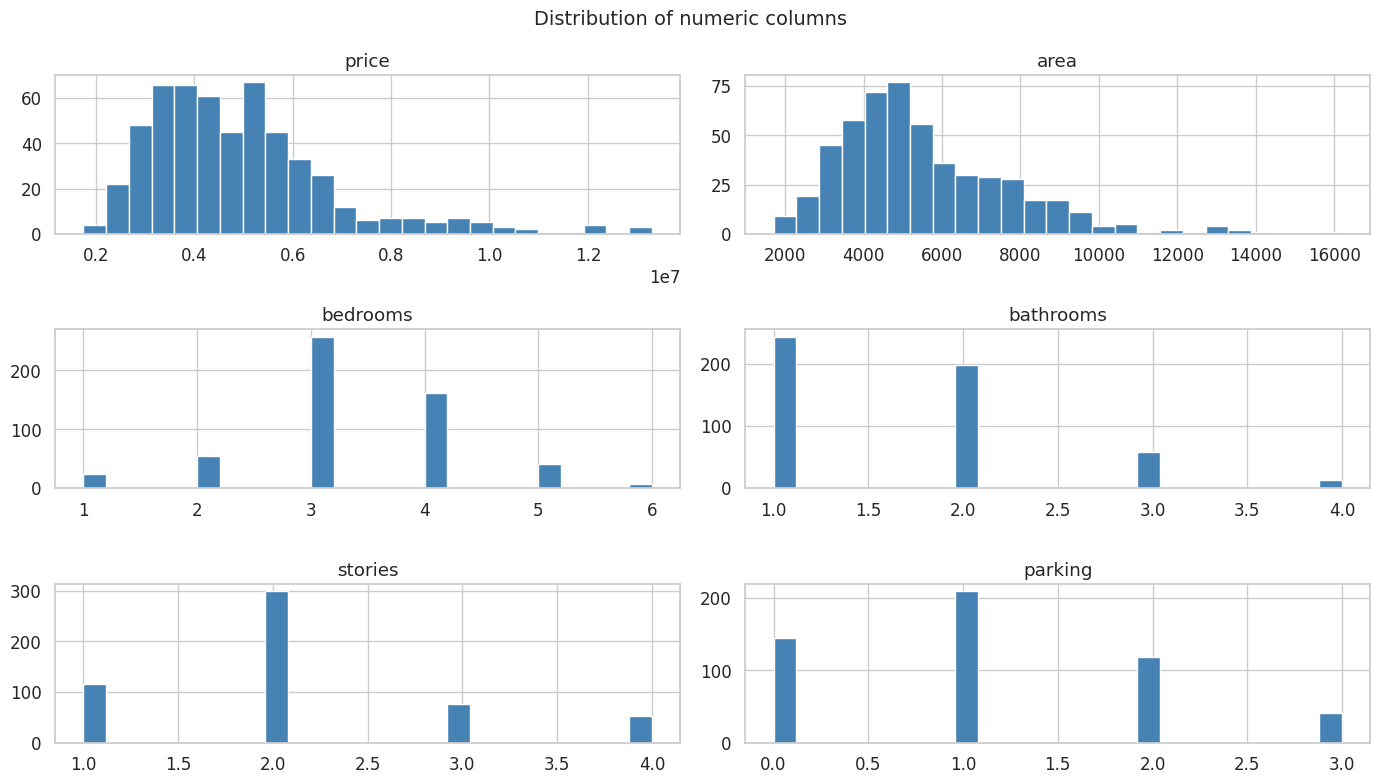

In [10]:
df[['price','area','bedrooms','bathrooms','stories','parking']].hist(
    bins=25, figsize=(14, 8), edgecolor='white', color='steelblue')
plt.suptitle("Distribution of numeric columns", fontsize=14)
plt.tight_layout()
plt.show()

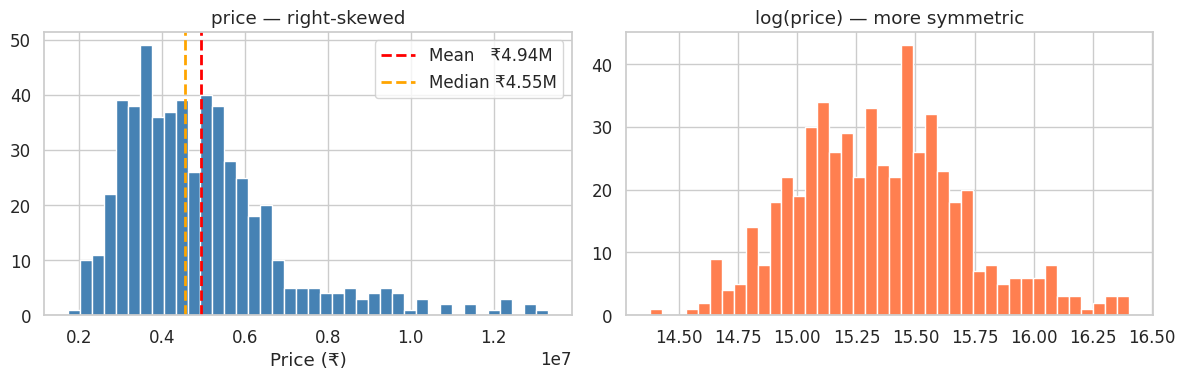

Skewness raw:   1.49
Skewness log:   0.34


In [11]:
# Zoom in on price
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['price'].hist(bins=40, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axvline(df['price'].mean(),   color='red',    ls='--', lw=2,
                label=f"Mean   ₹{df['price'].mean()/1e6:.2f}M")
axes[0].axvline(df['price'].median(), color='orange', ls='--', lw=2,
                label=f"Median ₹{df['price'].median()/1e6:.2f}M")
axes[0].set_title('price — right-skewed')
axes[0].set_xlabel('Price (₹)')
axes[0].legend()

np.log1p(df['price']).hist(bins=40, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('log(price) — more symmetric')
plt.tight_layout()
plt.show()

print(f"Skewness raw:   {df['price'].skew():.2f}")
print(f"Skewness log:   {np.log1p(df['price']).skew():.2f}")

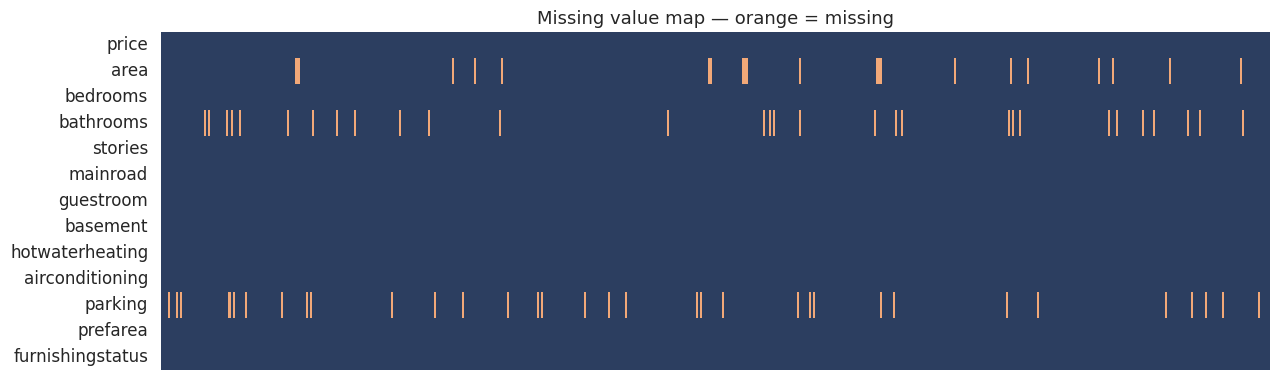

In [12]:
# Missing value heatmap — orange = missing cell
fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(df.isnull().T, cbar=False, yticklabels=True, xticklabels=False,
            cmap=['#2C3E60', '#F2A878'], ax=ax)
ax.set_title('Missing value map — orange = missing', fontsize=13)
plt.tight_layout()
plt.show()

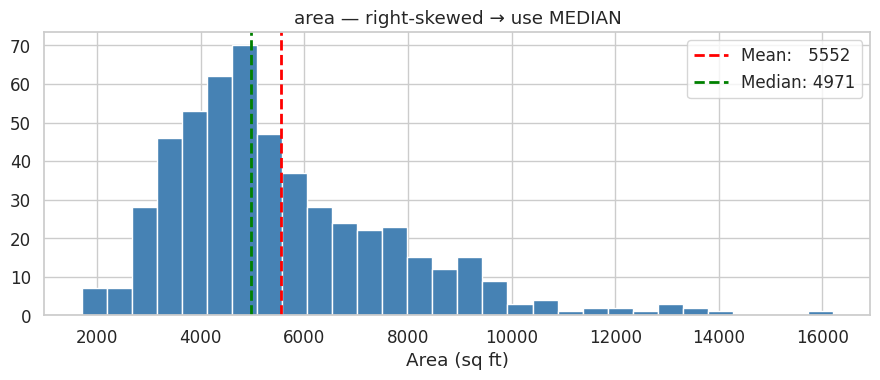

area skewness: 1.22  → right-skewed
Mean:   5552  vs  Median: 4971
→ Mean is pulled up by large houses. Median is safer.


In [13]:
# 1. area — should we use mean or median?
fig, ax = plt.subplots(figsize=(9, 4))
df['area'].dropna().hist(bins=30, ax=ax, color='steelblue', edgecolor='white')
ax.axvline(df['area'].mean(),   color='red',   ls='--', lw=2,
           label=f"Mean:   {df['area'].mean():.0f}")
ax.axvline(df['area'].median(), color='green', ls='--', lw=2,
           label=f"Median: {df['area'].median():.0f}")
ax.set_title('area — right-skewed → use MEDIAN')
ax.set_xlabel('Area (sq ft)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"area skewness: {df['area'].skew():.2f}  → right-skewed")
print(f"Mean:   {df['area'].mean():.0f}  vs  Median: {df['area'].median():.0f}")
print("→ Mean is pulled up by large houses. Median is safer.")

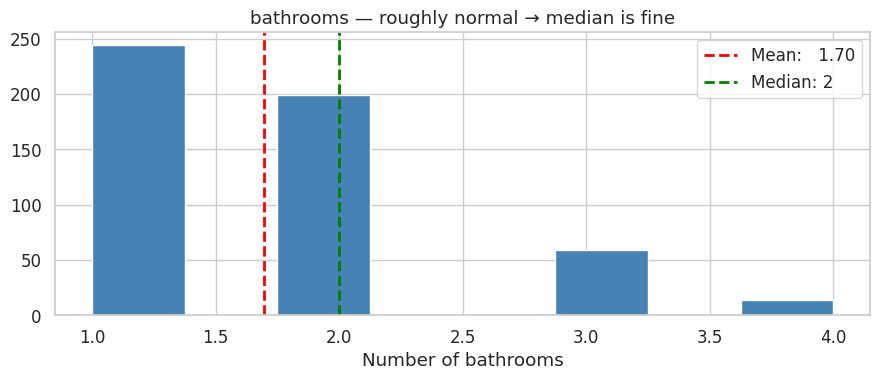

bathrooms skewness: 0.94


In [14]:
# 2. bathrooms — mean or median?
fig, ax = plt.subplots(figsize=(9, 4))
df['bathrooms'].dropna().hist(bins=8, ax=ax, color='steelblue', edgecolor='white')
ax.axvline(df['bathrooms'].mean(),   color='red',   ls='--', lw=2,
           label=f"Mean:   {df['bathrooms'].mean():.2f}")
ax.axvline(df['bathrooms'].median(), color='green', ls='--', lw=2,
           label=f"Median: {df['bathrooms'].median():.0f}")
ax.set_title('bathrooms — roughly normal → median is fine')
ax.set_xlabel('Number of bathrooms')
ax.legend()
plt.tight_layout()
plt.show()

print(f"bathrooms skewness: {df['bathrooms'].skew():.2f}")

In [15]:
# 3. parking — what is the mode (most common value)?
print("parking value counts:")
print(df['parking'].dropna().value_counts().sort_index().to_string())
print()
mode_val = df['parking'].mode()[0]
print(f"Mode (most common): {mode_val:.0f}")
print(f"→ Most houses have {mode_val:.0f} parking space(s).")
print("  For a count column like this, filling with MODE makes more sense than mean.")

parking value counts:
parking
0.0    145
1.0    209
2.0    118
3.0     41

Mode (most common): 1
→ Most houses have 1 parking space(s).
  For a count column like this, filling with MODE makes more sense than mean.


In [16]:
# Fill all three missing columns
df['area']      = df['area'].fillna(df['area'].median())
df['bathrooms'] = df['bathrooms'].fillna(df['bathrooms'].median())
df['parking']   = df['parking'].fillna(df['parking'].mode()[0])

print("Nulls after imputation:", df.isnull().sum().sum(), "✅")
print()
print("Verify — no more nulls in the three columns:")
print(df[['area','bathrooms','parking']].isnull().sum().to_string())

Nulls after imputation: 0 ✅

Verify — no more nulls in the three columns:
area         0
bathrooms    0
parking      0


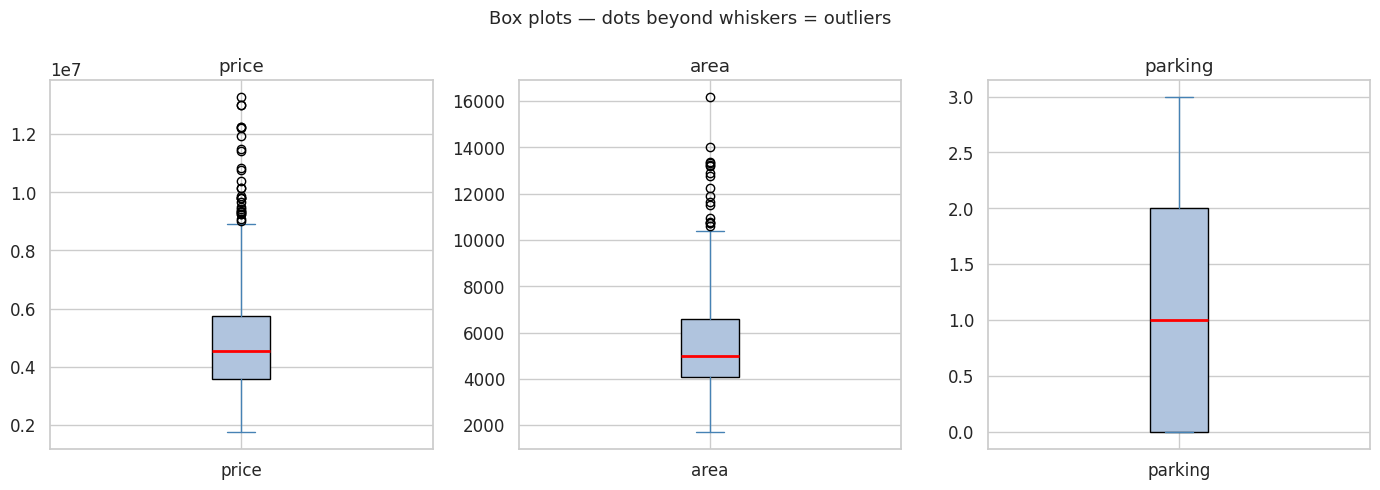

Outliers in price: 28 (5.1%) — keeping all (real properties)
Outliers in area: 17 (3.1%) — keeping all (real properties)


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, col in zip(axes, ['price', 'area', 'parking']):
    df[col].plot.box(ax=ax, color='steelblue', patch_artist=True,
                     boxprops=dict(facecolor='lightsteelblue'),
                     medianprops=dict(color='red', linewidth=2))
    ax.set_title(col)
plt.suptitle("Box plots — dots beyond whiskers = outliers", fontsize=13)
plt.tight_layout()
plt.show()

for col in ['price', 'area']:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n = ((df[col] < q1-1.5*iqr) | (df[col] > q3+1.5*iqr)).sum()
    print(f"Outliers in {col}: {n} ({n/len(df)*100:.1f}%) — keeping all (real properties)")

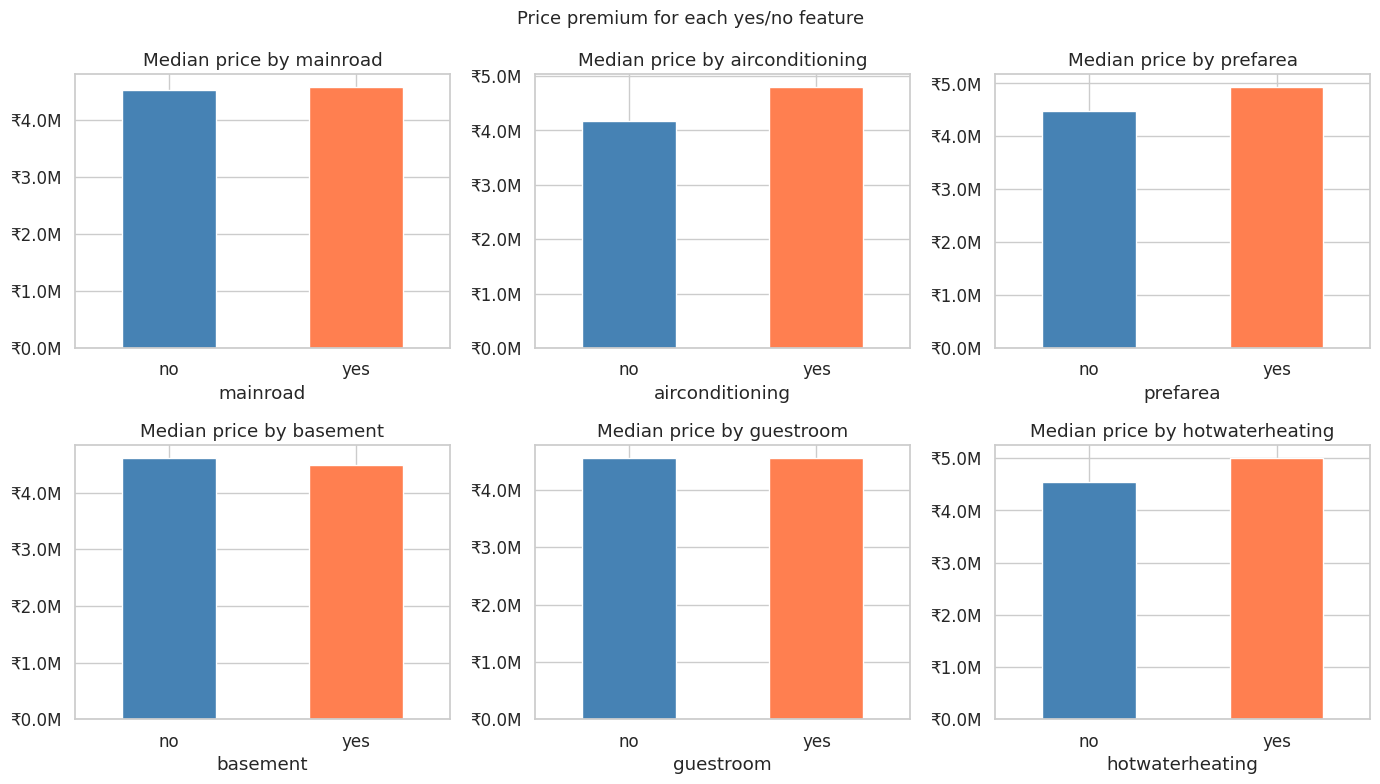

Price premium (yes vs no):
  mainroad            : +1%
  airconditioning     : +15%
  prefarea            : +10%
  basement            : -3%
  guestroom           : -0%
  hotwaterheating     : +10%


In [18]:
# Binary yes/no columns — price premium for each
binary_cols = ['mainroad','airconditioning','prefarea','basement','guestroom','hotwaterheating']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for ax, col in zip(axes, binary_cols):
    med = df.groupby(col)['price'].median()
    med.plot.bar(ax=ax, color=['steelblue','coral'], edgecolor='white', rot=0)
    ax.set_title(f'Median price by {col}')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'₹{x/1e6:.1f}M'))
plt.suptitle("Price premium for each yes/no feature", fontsize=13)
plt.tight_layout()
plt.show()

print("Price premium (yes vs no):")
for col in binary_cols:
    y = df[df[col]=='yes']['price'].median()
    n = df[df[col]=='no']['price'].median()
    print(f"  {col:<20}: {(y/n-1)*100:+.0f}%")

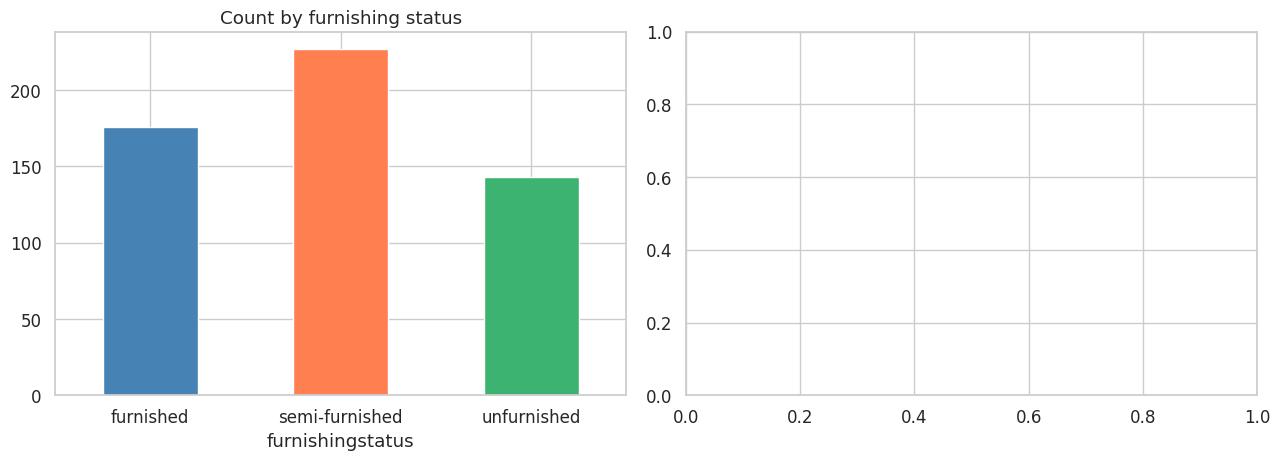

  furnished         : ₹5.17M median
  semi-furnished    : ₹4.57M median
  unfurnished       : ₹3.72M median
👉 Furnished > Semi-Furnished > Unfurnished — clear staircase!


In [19]:
# furnishingstatus — the 3-category column
order = ['furnished','semi-furnished','unfurnished']
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

df['furnishingstatus'].value_counts().reindex(order).plot.bar(
    ax=axes[0], color=['steelblue','coral','mediumseagreen'], edgecolor='white', rot=0)
axes[0].set_title('Count by furnishing status')

# df.boxplot(column='price', by='furnishingstatus', ax=axes[1], order=order,
#            boxprops=dict(color='steelblue'), medianprops=dict(color='red',linewidth=2))
# axes[1].set_title('Price by furnishing status')
# axes[1].set_xlabel('')
# axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'₹{x/1e6:.1f}M'))
plt.suptitle('')
plt.tight_layout()
plt.show()

for s in order:
    print(f"  {s:<18}: ₹{df[df['furnishingstatus']==s]['price'].median()/1e6:.2f}M median")
print("👉 Furnished > Semi-Furnished > Unfurnished — clear staircase!")

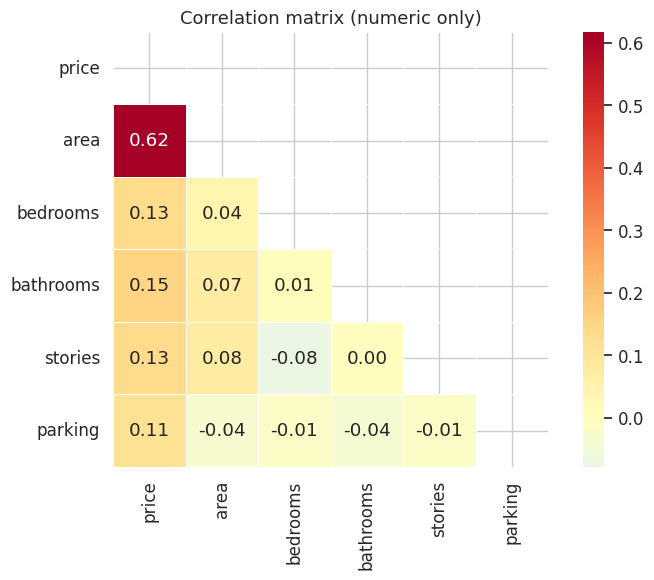

Correlations with price:
area         0.618
bathrooms    0.150
stories      0.132
bedrooms     0.131
parking      0.115


In [20]:
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, square=True, linewidths=0.5, mask=mask, ax=ax)
ax.set_title('Correlation matrix (numeric only)', fontsize=13)
plt.tight_layout()
plt.show()

target_corr = corr['price'].drop('price').sort_values(ascending=False)
print("Correlations with price:")
print(target_corr.round(3).to_string())

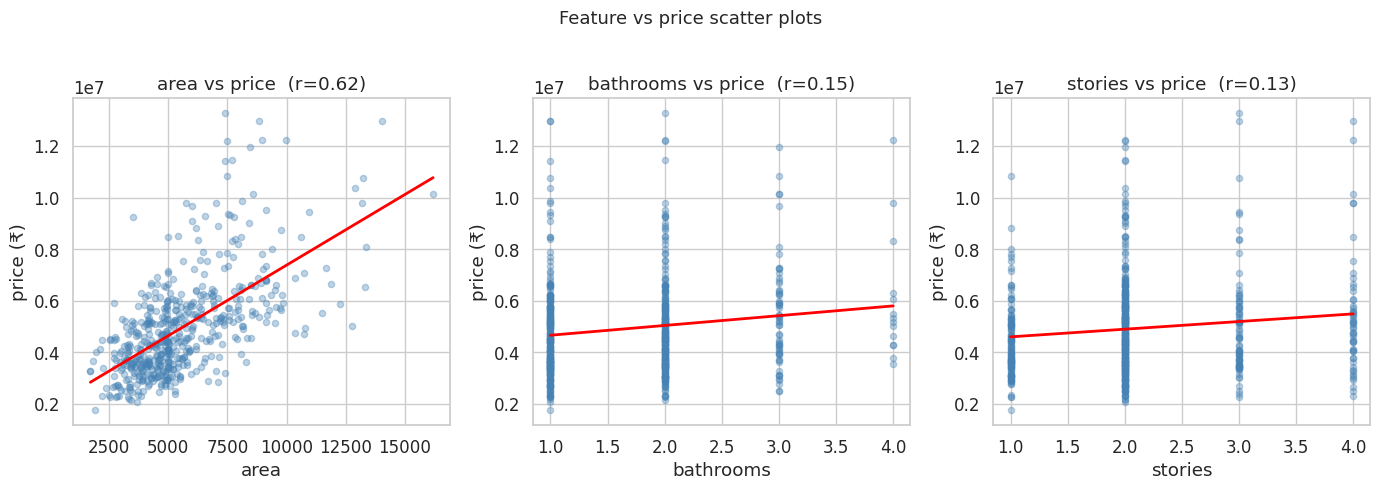

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, col in zip(axes, ['area','bathrooms','stories']):
    ax.scatter(df[col], df['price'], alpha=0.35, s=20, color='steelblue')
    m, b = np.polyfit(df[col].dropna(), df.loc[df[col].notna(),'price'], 1)
    xr = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(xr, m*xr+b, color='red', lw=2)
    ax.set_xlabel(col)
    ax.set_ylabel('price (₹)')
    ax.set_title(f'{col} vs price  (r={df[col].corr(df["price"]):.2f})')
plt.suptitle("Feature vs price scatter plots", fontsize=13)
plt.tight_layout()
plt.show()

In [22]:
# amenity_score: sum 5 comfort features
amenity_cols = ['guestroom','basement','hotwaterheating','airconditioning','prefarea']
for col in amenity_cols:
    df[col + '_num'] = (df[col] == 'yes').astype(int)
df['amenity_score'] = df[[c+'_num' for c in amenity_cols]].sum(axis=1)

print("Median price by amenity_score:")
print(df.groupby('amenity_score')['price'].median()
       .apply(lambda x: f'₹{x/1e6:.2f}M').to_string())
print(f"Correlation with price: {df['amenity_score'].corr(df['price']):.3f}")

Median price by amenity_score:
amenity_score
0    ₹4.07M
1    ₹4.55M
2    ₹4.49M
3    ₹4.83M
4    ₹5.24M
5    ₹6.44M
Correlation with price: 0.151


In [23]:
# room_total and area_per_room
df['room_total']    = df['bedrooms'] + df['bathrooms']
df['area_per_room'] = (df['area'] / df['room_total']).round(1)

print(f"room_total     r = {df['room_total'].corr(df['price']):.3f}")
print(f"area_per_room  r = {df['area_per_room'].corr(df['price']):.3f}")

room_total     r = 0.195
area_per_room  r = 0.381


In [24]:
# Map binary yes/no to 1/0
binary_cols = ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']
df_proc = df.copy()
for col in binary_cols:
    df_proc[col] = (df_proc[col] == 'yes').astype(int)

# One-hot encode furnishingstatus
df_proc = pd.get_dummies(df_proc, columns=['furnishingstatus'], drop_first=True)

print(f"Columns before: {df.shape[1]}  →  after encoding: {df_proc.shape[1]}")
new_cols = [c for c in df_proc.columns if 'furnishing' in c]
print("New furnishing columns:", new_cols)
print()
print("Sample (binary + furnishing columns):")
show = ['mainroad','airconditioning'] + new_cols + ['price']
print(df_proc[show].head(5).to_string())

Columns before: 21  →  after encoding: 22
New furnishing columns: ['furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']

Sample (binary + furnishing columns):
   mainroad  airconditioning  furnishingstatus_semi-furnished  furnishingstatus_unfurnished    price
0         1                0                            False                          True  3783554
1         0                0                            False                          True  2501180
2         0                1                            False                         False  4574919
3         1                1                             True                         False  6375421
4         1                1                            False                         False  5041867


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df_final = df_proc.copy()

# Drop helper columns from feature engineering
helper_cols = [c+'_num' for c in amenity_cols]
df_final = df_final.drop(columns=helper_cols, errors='ignore')

X = df_final.drop('price', axis=1)
y = df_final['price']
print(f"Features: {X.shape[1]} | Samples: {X.shape[0]}")

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

# Scale — fit ONLY on train!
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_test_scaled:  {X_test_scaled.shape}")
print("✅ Ready for Day 2 model training! 🚀")

Features: 16 | Samples: 546
Train: 436 | Test: 110
X_train_scaled: (436, 16)
X_test_scaled:  (110, 16)
✅ Ready for Day 2 model training! 🚀


In [26]:
print("=" * 52)
print("  EDA & PREPROCESSING COMPLETE")
print("=" * 52)
steps = [
    "Loaded 546 rows × 13 columns",
    "Found 84 missing cells in area/bathrooms/parking",
    "Imputed: area→median, bathrooms→median, parking→mode",
    "Explored 2 categoricals + 6 binary features",
    "Built correlation heatmap",
    "Engineered amenity_score, room_total, area_per_room",
    "Encoded yes/no→1/0, furnishing→one-hot",
    "80/20 train/test split + StandardScaler",
]
for s in steps:
    print(f"  ✅ {s}")
print()
print(f"  X_train_scaled: {X_train_scaled.shape}")
print(f"  X_test_scaled:  {X_test_scaled.shape}")

  EDA & PREPROCESSING COMPLETE
  ✅ Loaded 546 rows × 13 columns
  ✅ Found 84 missing cells in area/bathrooms/parking
  ✅ Imputed: area→median, bathrooms→median, parking→mode
  ✅ Explored 2 categoricals + 6 binary features
  ✅ Built correlation heatmap
  ✅ Engineered amenity_score, room_total, area_per_room
  ✅ Encoded yes/no→1/0, furnishing→one-hot
  ✅ 80/20 train/test split + StandardScaler

  X_train_scaled: (436, 16)
  X_test_scaled:  (110, 16)


In [27]:

print(f"Loaded: {df.shape[0]} rows x {df.shape[1]} columns")

# Impute (same strategy decided on Day 1 from the distributions)
df['area']      = df['area'].fillna(df['area'].median())
df['bathrooms'] = df['bathrooms'].fillna(df['bathrooms'].median())
df['parking']   = df['parking'].fillna(df['parking'].mode()[0])

# Encode
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    df[col] = (df[col] == 'yes').astype(int)
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

print("Nulls remaining:", df.isnull().sum().sum())
df.head()

Loaded: 546 rows x 21 columns
Nulls remaining: 0


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,...,guestroom_num,basement_num,hotwaterheating_num,airconditioning_num,prefarea_num,amenity_score,room_total,area_per_room,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,3783554,5593.0,4,4.0,2,1,0,1,0,0,...,0,1,0,0,1,2,8.0,699.1,False,True
1,2501180,5286.0,3,3.0,4,0,0,0,0,0,...,0,0,0,0,0,0,6.0,881.0,False,True
2,4574919,6378.0,2,2.0,2,0,1,1,0,1,...,1,1,0,1,0,3,4.0,1594.5,False,False
3,6375421,6954.0,3,2.0,2,1,1,1,0,1,...,1,1,0,1,1,4,5.0,1390.8,True,False
4,5041867,6064.0,4,2.0,2,1,0,0,0,1,...,0,0,0,1,0,1,6.0,1010.7,False,False


In [28]:
X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on TRAIN only
X_test_scaled  = scaler.transform(X_test)         # reuse the same fit on test

print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows | Features: {X_train.shape[1]}")

Train: 436 rows | Test: 110 rows | Features: 21


In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

reg_results = {}   # we'll keep appending to this table

def score_regressor(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    reg_results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f"{name:22s}  MAE = Rs.{mae:,.0f}   RMSE = Rs.{rmse:,.0f}   R2 = {r2:.3f}")
    return mae, rmse, r2

Linear Regression       MAE = Rs.1,035,220   RMSE = Rs.1,441,851   R2 = 0.431


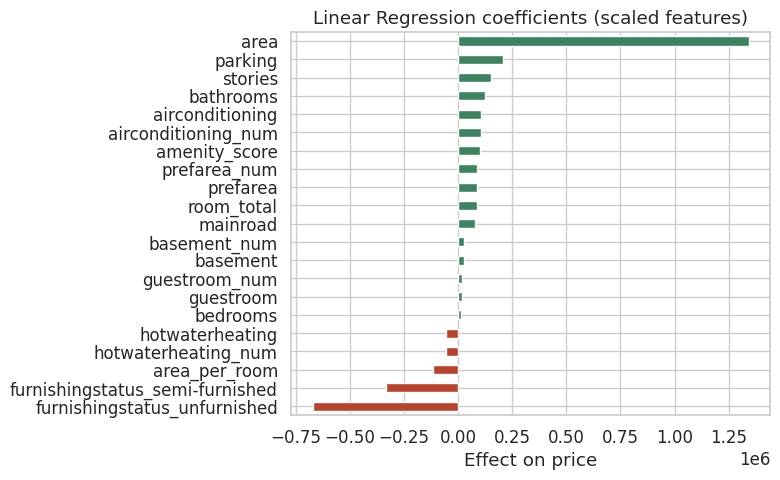

In [30]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)
y_pred_lin = lin_reg.predict(X_test_scaled)

score_regressor("Linear Regression", y_test, y_pred_lin)

# Which features push price up/down the most?
coefs = pd.Series(lin_reg.coef_, index=X.columns).sort_values()
plt.figure(figsize=(8, 5))
coefs.plot.barh(color=['#B6432C' if c < 0 else '#3D8361' for c in coefs])
plt.title("Linear Regression coefficients (scaled features)")
plt.xlabel("Effect on price")
plt.tight_layout()
plt.show()

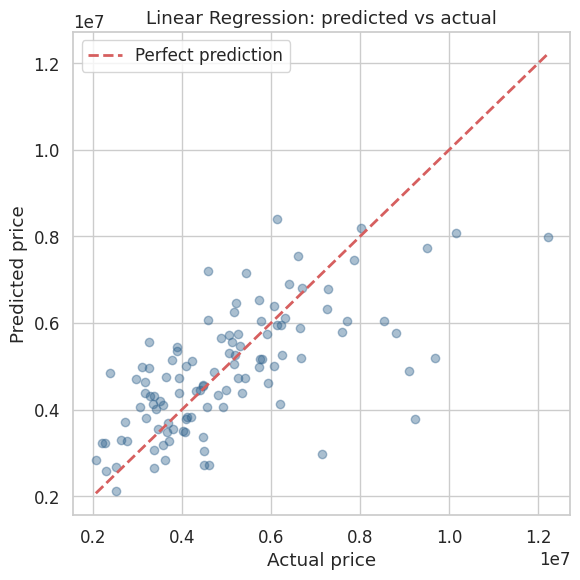

In [31]:
# Predicted vs actual - the classic regression sanity check.
# Points on the diagonal = perfect predictions.
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_lin, alpha=0.4, color='#2C5F8A')
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, 'r--', lw=2, label='Perfect prediction')
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("Linear Regression: predicted vs actual")
plt.legend()
plt.tight_layout()
plt.show()